<a href="https://colab.research.google.com/github/Chandana-dharshanam/ecg-detection/blob/main/ECG_Arrhythmia_Detection_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECG Arrhythmia Detection — MIT-BIH (v3: all beat types, fixed pipeline)

**Why v2 only seemed to show 2 beat types** (your notebook already had 5 classes in code — these are the reasons they didn't show up):

| # | Problem in v2 | Effect | Fix in v3 |
|---|---|---|---|
| 1 | Plot and summary coloured beats only **green (N) / red (everything else)** | Visually only 2 types | One colour + label per class (N, S, V, F) |
| 2 | **Q class is almost empty** in DS1/DS2 (paced records 102/104/107/217 are excluded by the standard split; only ~8 Q beats per set) | Q can never be learned or tested | Q is off by default (`USE_Q = False`), standard practice |
| 3 | Pan-Tompkins peaks were the peak of the *integrated envelope*, not the R-peak | Beat windows misaligned vs. training (trained on true R-peaks) → model confused, rare classes collapse into N/V | Validated `xqrs` detector + R-peak refinement + shift augmentation |
| 4 | RR features used **all annotations** incl. non-beat marks (`+`, `~`) | Wrong RR for neighbouring beats | Only real beat annotations are used |
| 5 | Oversampling happened **before** `validation_split` | Duplicates leaked into validation → early stopping trusted a fake val-loss | Split first, oversample train only |
| 6 | `GlobalAveragePooling` discards *where* in the beat features occur; RR features were unscaled | Weak morphology signal (P-wave absence, QRS width) | Flatten head + standardised, richer RR features |
| 7 | Oversampling **and** alpha weights **and** focal loss all at once | Over-corrects / unstable | Oversampling + focal loss only |

**Honest expectation:** N and V are easy (>95% sensitivity is normal). **S and F are genuinely hard** in inter-patient testing (published results are typically ~50–85% sensitivity). Use the diagnostics in Section 9 to see exactly where each class goes.

In [1]:
# 1. Install dependencies (Colab)
!pip install -q wfdb tensorflow scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.3 MB/s eta 0:00:00


In [2]:
import os, json
import numpy as np
import wfdb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
from collections import Counter

FS = 360
DATA_DIR = "mitdb"
os.makedirs(DATA_DIR, exist_ok=True)

# Standard inter-patient split (de Chazal et al.). Paced records 102,104,107,217 are excluded.
DS1 = ['101','106','108','109','112','114','115','116','118','119','122','124',
       '201','203','205','207','208','209','215','220','223','230']
DS2 = ['100','103','105','111','113','117','121','123','200','202','210','212',
       '213','214','219','221','222','228','231','232','233','234']
RECORDS_TO_USE = DS1 + DS2      # quick test: DS1[:8] + DS2[:8]

USE_Q = False                    # Q (paced/unknown) has ~8 beats in DS1/DS2 -> not learnable
AAMI_MAP = {'N':'N','L':'N','R':'N','e':'N','j':'N',
            'A':'S','a':'S','J':'S','S':'S',
            'V':'V','E':'V',
            'F':'F'}
if USE_Q:
    AAMI_MAP.update({'/':'Q','f':'Q','Q':'Q','U':'Q'})
CLASSES = ['N','S','V','F'] + (['Q'] if USE_Q else [])
CLASS_TO_IDX = {c:i for i,c in enumerate(CLASSES)}
N_CLASSES = len(CLASSES)
# every symbol that is a real heartbeat (used for RR intervals & detection scoring)
ALL_BEAT_SYMBOLS = set("NLRBAaJSVrFejnE/fQ?") | set(AAMI_MAP)

def download_records(record_names, data_dir=DATA_DIR):
    missing = [r for r in record_names if not os.path.exists(os.path.join(data_dir, r + ".dat"))]
    for r in missing:
        wfdb.dl_database('mitdb', dl_dir=data_dir, records=[r])
    print(f"{len(record_names)} records ready ({len(missing)} downloaded).")

download_records(RECORDS_TO_USE)

Generating record list for: 101
Generating list of all files for: 101
Finished downloading files
Generating record list for: 106
Generating list of all files for: 106
Finished downloading files
Generating record list for: 108
Generating list of all files for: 108
Finished downloading files
Generating record list for: 109
Generating list of all files for: 109
Finished downloading files
Generating record list for: 112
Generating list of all files for: 112
Finished downloading files
Generating record list for: 114
Generating list of all files for: 114
Finished downloading files
Generating record list for: 115
Generating list of all files for: 115
Finished downloading files
Generating record list for: 116
Generating list of all files for: 116
Finished downloading files
Generating record list for: 118
Generating list of all files for: 118
Finished downloading files
Generating record list for: 119
Generating list of all files for: 119
Finished downloading files
Generating record list for: 12

## 2. Preprocessing

In [3]:
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=FS, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

def normalize(signal):
    return (signal - np.mean(signal)) / (np.std(signal) + 1e-8)

def load_record(rec_name, data_dir=DATA_DIR):
    """Returns (z-scored signal for the model, band-passed signal in mV for detection, annotation)."""
    path = os.path.join(data_dir, rec_name)
    record = wfdb.rdrecord(path)
    annotation = wfdb.rdann(path, 'atr')
    raw = record.p_signal[:, 0]                 # MLII lead
    filt_mv = bandpass_filter(raw)
    return normalize(filt_mv), filt_mv, annotation

def beat_annotations(annotation):
    """Keep only real heartbeat annotations (drops '+', '~', '|' ... marks)."""
    sym = np.array(annotation.symbol)
    mask = np.array([s in ALL_BEAT_SYMBOLS for s in sym])
    return annotation.sample[mask], sym[mask]

## 3. Beat Detection
Default is `wfdb.processing.xqrs_detect` (a validated QRS detector built for MIT-BIH), with a simplified Pan-Tompkins as fallback. Detected points are snapped to the true R-peak so windows line up with how the model was trained. `evaluate_detection` scores detector sensitivity / PPV against the expert annotations (±150 ms).

In [4]:
from wfdb import processing
from scipy.signal import find_peaks
from scipy.ndimage import median_filter

def pan_tompkins_detector(filt_mv, fs=FS):
    """Simplified Pan-Tompkins with a local (median-based) adaptive threshold."""
    det = bandpass_filter(filt_mv, 5, 15, fs)
    sq = np.diff(det, prepend=det[0]) ** 2
    win = int(0.12 * fs)
    integ = np.convolve(sq, np.ones(win) / win, mode='same')
    cand, _ = find_peaks(integ, distance=int(0.2 * fs))
    if len(cand) == 0:
        return np.array([], dtype=int)
    h = integ[cand]
    ref = median_filter(h, size=15, mode='nearest')
    return cand[h > 0.25 * ref]

def refine_to_rpeak(sig, peaks, fs=FS, radius_s=0.05):
    r = int(radius_s * fs)
    out = []
    for p in peaks:
        a, b = max(0, p - r), min(len(sig), p + r + 1)
        out.append(a + int(np.argmax(np.abs(sig[a:b]))))
    out = np.unique(out)
    # enforce 200 ms refractory period, keep the larger deflection
    keep = []
    for p in out:
        if keep and p - keep[-1] < int(0.2 * fs):
            if abs(sig[p]) > abs(sig[keep[-1]]):
                keep[-1] = p
        else:
            keep.append(p)
    return np.array(keep, dtype=int)

def detect_r_peaks(filt_mv, fs=FS, method='xqrs'):
    peaks = np.array([], dtype=int)
    if method == 'xqrs':
        try:
            peaks = np.asarray(processing.xqrs_detect(sig=filt_mv, fs=fs, verbose=False), dtype=int)
        except Exception as e:
            print("xqrs failed, falling back to Pan-Tompkins:", e)
    if len(peaks) == 0:
        peaks = pan_tompkins_detector(filt_mv, fs)
    return refine_to_rpeak(filt_mv, peaks, fs)

def evaluate_detection(pred, ref, fs=FS, tol_s=0.15):
    pred, ref = np.asarray(pred), np.asarray(ref)
    tol = int(tol_s * fs); used = np.zeros(len(ref), bool); tp = 0
    for p in pred:
        j = np.searchsorted(ref, p)
        c = [k for k in (j - 1, j) if 0 <= k < len(ref)]
        if not c: continue
        k = min(c, key=lambda k: abs(ref[k] - p))
        if abs(ref[k] - p) <= tol and not used[k]:
            used[k] = True; tp += 1
    fp, fn = len(pred) - tp, len(ref) - tp
    return tp / max(tp + fn, 1), tp / max(tp + fp, 1)

## 4. Beat Segmentation + RR Features + AAMI Labels
Each beat = **200-sample waveform** (90 before / 110 after the R-peak) + **6 rhythm features**: previous RR, next RR, prev/next ratio, prev/local-average, next/local-average, local-average RR (mean of last 8 beats). The same functions are used for training *and* live inference, so they can't drift apart.

In [5]:
WINDOW_BEFORE, WINDOW_AFTER = 90, 110
N_RR = 6

def rr_features(peaks, fs=FS, n_avg=8):
    peaks = np.asarray(peaks); n = len(peaks)
    if n < 2:
        return np.zeros((n, N_RR))
    rr = np.diff(peaks) / fs
    prev = np.r_[rr[0], rr]
    nxt = np.r_[rr, rr[-1]]
    avg = np.array([prev[max(0, i - n_avg + 1):i + 1].mean() for i in range(n)])
    f = np.c_[prev, nxt,
              np.clip(prev / np.maximum(nxt, 1e-3), 0, 5),
              np.clip(prev / np.maximum(avg, 1e-3), 0, 5),
              np.clip(nxt / np.maximum(avg, 1e-3), 0, 5),
              avg]
    return f

def extract_windows(signal, peaks):
    peaks = np.asarray(peaks)
    valid = (peaks - WINDOW_BEFORE >= 0) & (peaks + WINDOW_AFTER <= len(signal))
    if not valid.any():
        return np.zeros((0, WINDOW_BEFORE + WINDOW_AFTER)), valid
    W = np.stack([signal[p - WINDOW_BEFORE:p + WINDOW_AFTER] for p in peaks[valid]])
    return W, valid

def build_dataset(record_names, data_dir=DATA_DIR, jitter=False, seed=0):
    """Beats from expert annotations. jitter=True shifts windows +-4 samples so the model
    tolerates small R-peak location errors from the automatic detector."""
    rng = np.random.default_rng(seed)
    Xs, RRs, ys, frac = [], [], [], []
    for rec in record_names:
        sig, _, ann = load_record(rec, data_dir)
        samples, syms = beat_annotations(ann)
        feats = rr_features(samples)                 # computed on ALL real beats
        shift = rng.integers(-4, 5, len(samples)) if jitter else np.zeros(len(samples), int)
        W, valid = extract_windows(sig, samples + shift)
        keep = np.array([s in AAMI_MAP for s in syms]) & valid
        # W only contains rows for `valid`, so map back
        idx_valid = np.where(valid)[0]
        row_ok = keep[idx_valid]
        Xs.append(W[row_ok]); RRs.append(feats[idx_valid][row_ok])
        ys.append(np.array([CLASS_TO_IDX[AAMI_MAP[s]] for s in syms[idx_valid][row_ok]]))
        frac.append(idx_valid[row_ok] / max(len(samples), 1))   # position of beat within record
    return (np.concatenate(Xs), np.concatenate(RRs),
            np.concatenate(ys), np.concatenate(frac))

## 5. Inter-Patient Split (DS1 train / DS2 test) + Validation Set
**DS2 is never touched during training.** For validation (early stopping) we hold out the *last 15 % of every DS1 record in time*, taken **before** oversampling so no duplicates leak.

In [6]:
train_records = [r for r in RECORDS_TO_USE if r in DS1]
test_records  = [r for r in RECORDS_TO_USE if r in DS2]

X_all, RR_all, y_all, frac_all = build_dataset(train_records, jitter=True)
X_test, RR_test, y_test, _     = build_dataset(test_records, jitter=False)

is_val = frac_all >= 0.85
X_train, RR_train, y_train = X_all[~is_val], RR_all[~is_val], y_all[~is_val]
X_val,   RR_val,   y_val   = X_all[is_val],  RR_all[is_val],  y_all[is_val]

show = lambda y: {CLASSES[k]: int(v) for k, v in sorted(Counter(y).items())}
print("Train:", X_train.shape, show(y_train))
print("Val  :", X_val.shape,   show(y_val))
print("Test :", X_test.shape,  show(y_test))

Train: (43364, 200) {'N': 39119, 'S': 735, 'V': 3122, 'F': 388}
Val  : (7636, 200) {'N': 6735, 'S': 209, 'V': 666, 'F': 26}
Test : (49690, 200) {'N': 44245, 'S': 1837, 'V': 3220, 'F': 388}


## 6. Oversample Minority Classes (train only) + Standardise RR
Duplicates get random amplitude scaling (±10 %), small time shifts (±3 samples) and noise, so they are not exact copies.

In [7]:
def oversample(X, RR, y, target_ratio=0.4, seed=42):
    rng = np.random.default_rng(seed)
    counts = Counter(y); target = int(max(counts.values()) * target_ratio)
    Xo, RRo, yo = [X], [RR], [y]
    for cls, cnt in counts.items():
        if cnt >= target: continue
        n = target - cnt
        pick = rng.choice(np.where(y == cls)[0], n, replace=True)
        W = X[pick] * rng.uniform(0.9, 1.1, (n, 1))
        shifts = rng.integers(-3, 4, n)
        W = np.stack([np.roll(w, s) for w, s in zip(W, shifts)])
        W = W + rng.normal(0, 0.02, W.shape)
        R = RR[pick] * rng.uniform(0.98, 1.02, (n, 1))
        Xo.append(W); RRo.append(R); yo.append(y[pick])
    Xf, Rf, yf = np.concatenate(Xo), np.concatenate(RRo), np.concatenate(yo)
    p = rng.permutation(len(yf))
    return Xf[p], Rf[p], yf[p]

# RR scaling statistics come from the ORIGINAL train set only
RR_MEAN, RR_STD = RR_train.mean(0), RR_train.std(0) + 1e-6
scale_rr = lambda r: ((r - RR_MEAN) / RR_STD).astype('float32')

X_train_os, RR_train_os, y_train_os = oversample(X_train, RR_train, y_train, target_ratio=0.4)
print("After oversampling:", show(y_train_os))

f_wave = lambda x: x[..., None].astype('float32')
Xtr, Rtr = f_wave(X_train_os), scale_rr(RR_train_os)
Xva, Rva = f_wave(X_val),      scale_rr(RR_val)
Xte, Rte = f_wave(X_test),     scale_rr(RR_test)

After oversampling: {'N': 39119, 'S': 15647, 'V': 15647, 'F': 15647}


## 7. Model — Two-Branch CNN (waveform + rhythm)
Flatten head keeps positional information (is there a P-wave *before* the QRS? how wide is the QRS?). Still tiny (~100 k parameters) for edge deployment.

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_model(waveform_shape=(WINDOW_BEFORE + WINDOW_AFTER, 1), rr_shape=(N_RR,), n_classes=N_CLASSES):
    w_in = layers.Input(shape=waveform_shape, name='waveform')
    x = layers.Conv1D(16, 7, padding='same', activation='relu')(w_in)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(32, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(48, activation='relu')(x)

    r_in = layers.Input(shape=rr_shape, name='rr_features')
    r = layers.Dense(16, activation='relu')(r_in)
    r = layers.Dense(16, activation='relu')(r)

    h = layers.Concatenate()([x, r])
    h = layers.Dense(32, activation='relu')(h)
    h = layers.Dropout(0.3)(h)
    out = layers.Dense(n_classes, activation='softmax', name='beat_class')(h)
    return Model([w_in, r_in], out)

def sparse_focal_loss(gamma=2.0, n_classes=N_CLASSES):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        oh = tf.one_hot(y_true, n_classes)
        return tf.reduce_sum(-oh * tf.pow(1 - y_pred, gamma) * tf.math.log(y_pred), axis=-1)
    return loss_fn

model = build_model()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=sparse_focal_loss(2.0), metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ waveform            │ (None, 200, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 16)   │        128 │ waveform[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 16)   │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 100, 16)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 32)   │      2,592 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 50, 32)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 50, 64)    │      6,208 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 25, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr_features         │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1600)      │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        112 │ rr_features[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 48)        │     76,848 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        272 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ beat_class (Dense)  │ (None, 4)         │        132 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 88,820 (346.95 KB)

 Trainable params: 88,596 (346.08 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/10
673/673 - 38s - 57ms/step - accuracy: 0.9964 - loss: 0.0033 - val_accuracy: 0.9652 - val_loss: 0.2562 - learning_rate: 5.0000e-04
Epoch 2/10
673/673 - 39s - 58ms/step - accuracy: 0.9963 - loss: 0.0032 - val_accuracy: 0.9350 - val_loss: 0.3052 - learning_rate: 5.0000e-04
Epoch 3/10
673/673 - 39s - 57ms/step - accuracy: 0.9968 - loss: 0.0029 - val_accuracy: 0.9686 - val_loss: 0.2578 - learning_rate: 5.0000e-04
Epoch 4/10
673/673 - 38s - 56ms/step - accuracy: 0.9972 - loss: 0.0024 - val_accuracy: 0.9656 - val_loss: 0.2621 - learning_rate: 5.0000e-04
Epoch 5/10
673/673 - 37s - 55ms/step - accuracy: 0.9980 - loss: 0.0016 - val_accuracy: 0.9669 - val_loss: 0.2574 - learning_rate: 2.5000e-04
Epoch 6/10
673/673 - 40s - 60ms/step - accuracy: 0.9981 - loss: 0.0014 - val_accuracy: 0.9763 - val_loss: 0.2514 - learning_rate: 2.5000e-04
Epoch 7/10
673/673 - 38s - 56ms/step - accuracy: 0.9987 - loss: 0.0011 - val_accuracy: 0.9725 - val_loss: 0.2548 - learning_rate: 2.5000e-04
Epoch 8/10
67

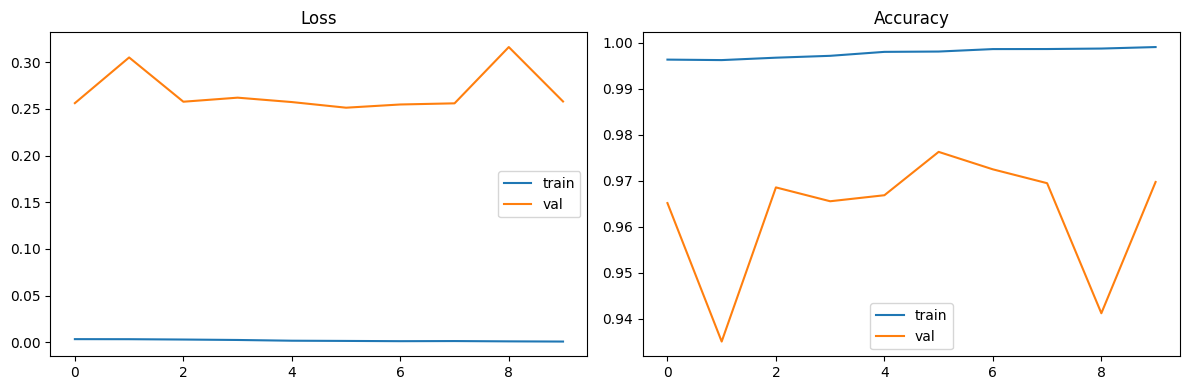

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3),
]
history = model.fit({'waveform': Xtr, 'rr_features': Rtr}, y_train_os,
                    validation_data=({'waveform': Xva, 'rr_features': Rva}, y_val),
                    epochs=10, batch_size=128, callbacks=callbacks, verbose=2)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='train'); ax[0].plot(history.history['val_loss'], label='val'); ax[0].set_title('Loss'); ax[0].legend()
ax[1].plot(history.history['accuracy'], label='train'); ax[1].plot(history.history['val_accuracy'], label='val'); ax[1].set_title('Accuracy'); ax[1].legend()
plt.tight_layout(); plt.show()

## 8. Evaluation on the untouched DS2 test set
Reports per-class sensitivity, specificity, F1, macro-F1 and **false alarms per minute** (using the real recording length).

              precision    recall  f1-score   support

           N     0.9595    0.9698    0.9646     44245
           S     0.2886    0.1181    0.1676      1837
           V     0.8701    0.9295    0.8988      3220
           F     0.0540    0.1082    0.0720       388

    accuracy                         0.9290     49690
   macro avg     0.5430    0.5314    0.5258     49690
weighted avg     0.9218    0.9290    0.9239     49690

class   sensitivity  specificity
N            0.9698       0.6674
S            0.1181       0.9888
V            0.9295       0.9904
F            0.1082       0.9851


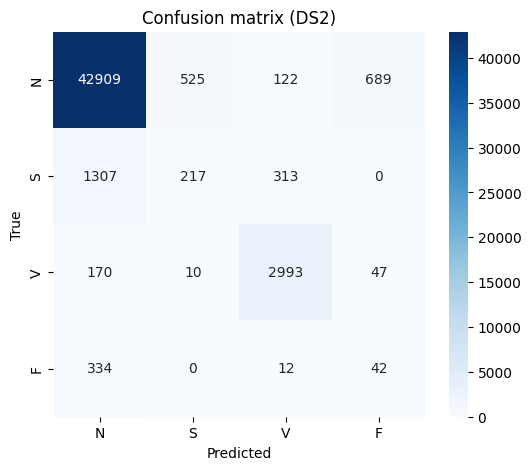


Test duration: 662.0 min
False alarms per minute (Normal flagged abnormal): 2.018
   false 'S' alarms/min: 0.808
   false 'V' alarms/min: 0.675
   false 'F' alarms/min: 1.112
Macro-F1: 0.5258


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_prob = model.predict({'waveform': Xte, 'rr_features': Rte}, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
labels = list(range(N_CLASSES))

print(classification_report(y_test, y_pred, labels=labels, target_names=CLASSES, digits=4, zero_division=0))
cm = confusion_matrix(y_test, y_pred, labels=labels)

rows = []
total = cm.sum()
for i, c in enumerate(CLASSES):
    TP = cm[i, i]; FN = cm[i].sum() - TP; FP = cm[:, i].sum() - TP; TN = total - TP - FN - FP
    rows.append((c, TP / max(TP + FN, 1), TN / max(TN + FP, 1)))
print(f"{'class':<6}{'sensitivity':>13}{'specificity':>13}")
for c, se, sp in rows: print(f"{c:<6}{se:>13.4f}{sp:>13.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion matrix (DS2, 5-class view)' if USE_Q else 'Confusion matrix (DS2)')
plt.show()

test_minutes = sum(wfdb.rdheader(os.path.join(DATA_DIR, r)).sig_len for r in test_records) / FS / 60
n_idx = CLASS_TO_IDX['N']
fa = np.sum((y_pred != n_idx) & (y_test == n_idx))
print(f"\nTest duration: {test_minutes:.1f} min")
print(f"False alarms per minute (Normal flagged abnormal): {fa / test_minutes:.3f}")
for c in CLASSES[1:]:
    k = CLASS_TO_IDX[c]
    print(f"   false '{c}' alarms/min: {np.sum((y_pred == k) & (y_test != k)) / test_minutes:.3f}")
macro_f1 = classification_report(y_test, y_pred, labels=labels, output_dict=True, zero_division=0)['macro avg']['f1-score']
print(f"Macro-F1: {macro_f1:.4f}")

### Diagnostic: is the model really using all classes?
If a class shows up in **True** but never in **Predicted**, the model has collapsed on it — try `target_ratio` 0.4 → 0.7 in Section 6 or `gamma` 2 → 3 in Section 7.

class     true  predicted
N        44245      44720
S         1837        752
V         3220       3440
F          388        778


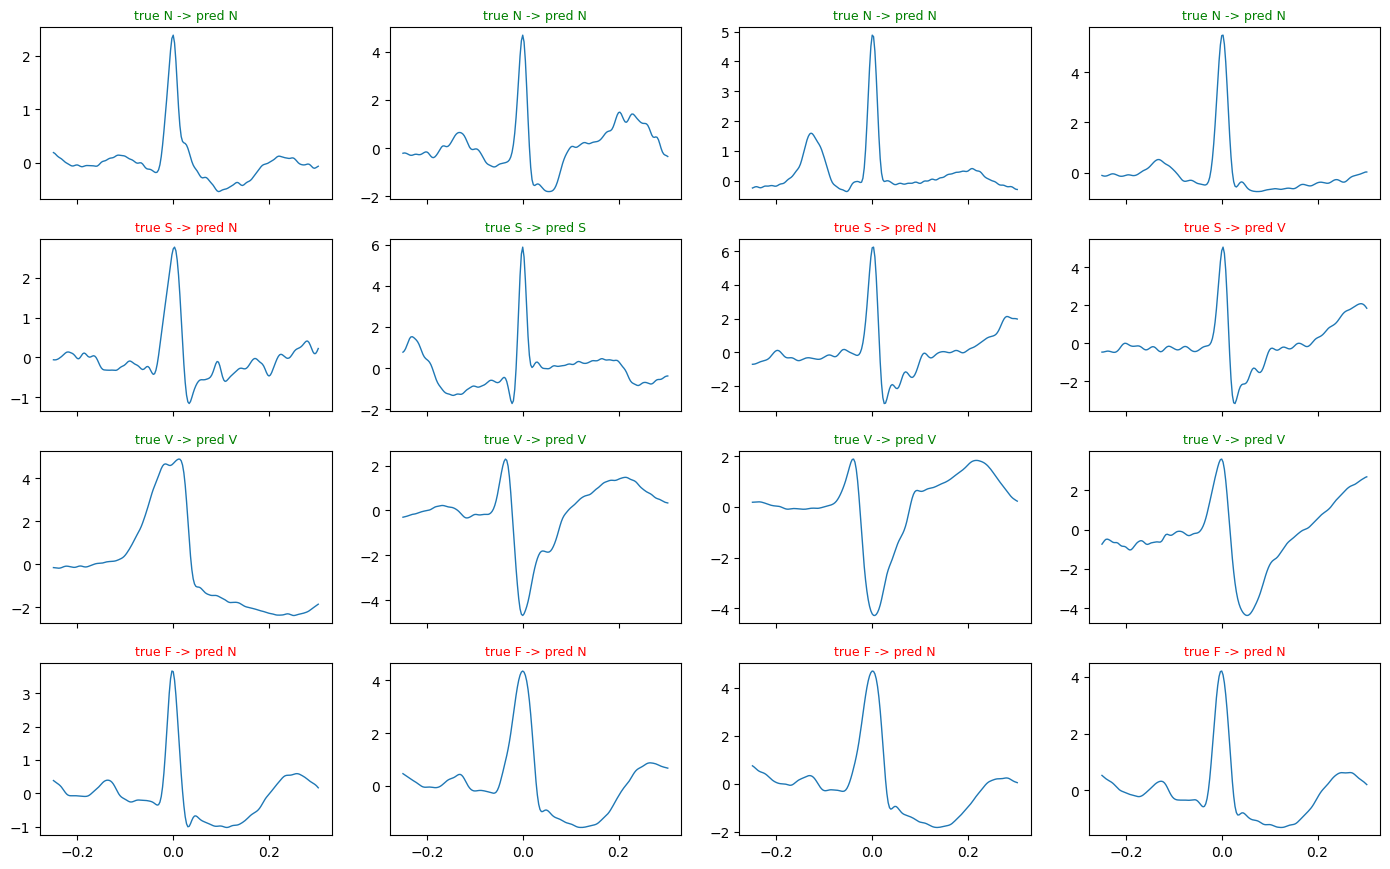

In [12]:
tc, pc = Counter(y_test), Counter(y_pred)
print(f"{'class':<6}{'true':>8}{'predicted':>11}")
for i, c in enumerate(CLASSES): print(f"{c:<6}{tc.get(i,0):>8}{pc.get(i,0):>11}")

# Example test beats for EVERY class (green title = correct, red = wrong)
fig, axes = plt.subplots(N_CLASSES, 4, figsize=(14, 2.2 * N_CLASSES), sharex=True)
rng = np.random.default_rng(1); t = (np.arange(WINDOW_BEFORE + WINDOW_AFTER) - WINDOW_BEFORE) / FS
for i, c in enumerate(CLASSES):
    idx = np.where(y_test == i)[0]
    for j in range(4):
        ax = axes[i, j]; ax.axis('off') if len(idx) == 0 else None
        if len(idx) == 0: continue
        k = rng.choice(idx); ax.plot(t, X_test[k], lw=1)
        ax.set_title(f"true {c} -> pred {CLASSES[y_pred[k]]}", fontsize=9, color='green' if y_pred[k] == i else 'red')
plt.tight_layout(); plt.show()

## 9. Binary view — Normal vs Abnormal

In [13]:
yb_t = (y_test != n_idx).astype(int); yb_p = (y_pred != n_idx).astype(int)
print(classification_report(yb_t, yb_p, target_names=['Normal', 'Abnormal'], digits=4, zero_division=0))

              precision    recall  f1-score   support

      Normal     0.9595    0.9698    0.9646     44245
    Abnormal     0.7312    0.6674    0.6978      5445

    accuracy                         0.9367     49690
   macro avg     0.8453    0.8186    0.8312     49690
weighted avg     0.9345    0.9367    0.9354     49690



## 10. End-to-end: detect beats → classify → display
`predict_record` runs the *real* pipeline (automatic detector, not annotations), reports detector sensitivity/PPV, gives the count and % of **every** beat type, compares against expert labels, and plots the ECG with **each class in its own colour** and abnormal regions shaded.

Run the next cell to define everything, then the cell after that will **ask you to type in a record number** (any of the 48 MIT-BIH records) and show that record's full beat classification.

In [14]:
CLASS_COLORS = {'N': 'tab:green', 'S': 'tab:orange', 'V': 'tab:red', 'F': 'tab:purple', 'Q': 'tab:gray'}

def classify_signal(filt_mv, sig_z, method='xqrs'):
    peaks = detect_r_peaks(filt_mv, method=method)
    feats = rr_features(peaks)
    W, valid = extract_windows(sig_z, peaks)
    peaks_v, feats_v = peaks[valid], feats[valid]
    probs = model.predict({'waveform': f_wave(W), 'rr_features': scale_rr(feats_v)}, verbose=0)
    return peaks_v, probs

def predict_record(record_name, data_dir=DATA_DIR, plot_seconds=10, plot_start_sec=None):
    if not os.path.exists(os.path.join(data_dir, record_name + ".dat")):
        wfdb.dl_database('mitdb', dl_dir=data_dir, records=[record_name])
    sig_z, filt_mv, ann = load_record(record_name, data_dir)
    peaks, probs = classify_signal(filt_mv, sig_z)
    if len(peaks) == 0:
        print("No valid beats detected."); return None
    pred = np.argmax(probs, axis=1); labels_pred = np.array([CLASSES[c] for c in pred])

    ref_s, ref_sym = beat_annotations(ann)
    sens, ppv = evaluate_detection(peaks, ref_s)
    counts = Counter(labels_pred); n = len(peaks)
    print(f"Record {record_name} | detector sensitivity {sens:.3f}, PPV {ppv:.3f} vs expert annotations")
    print(f"Total beats detected: {n}\n")
    print(f"{'Beat type':<10}{'Count':>8}{'Percent':>10}")
    print('-' * 28)
    for c in CLASSES:
        print(f"{c:<10}{counts.get(c, 0):>8}{100 * counts.get(c, 0) / n:>9.2f}%")
    print('-' * 28)
    abn = labels_pred != 'N'
    print(f"{'Abnormal':<10}{abn.sum():>8}{100 * abn.mean():>9.2f}%")

    # agreement with expert labels (beats matched within 150 ms)
    tol = int(0.15 * FS); agree = tot = 0; per = {c: [0, 0] for c in CLASSES}
    for p, lab in zip(peaks, labels_pred):
        j = np.searchsorted(ref_s, p); c = [k for k in (j - 1, j) if 0 <= k < len(ref_s)]
        if not c: continue
        k = min(c, key=lambda k: abs(ref_s[k] - p))
        if abs(ref_s[k] - p) <= tol and ref_sym[k] in AAMI_MAP:
            true = AAMI_MAP[ref_sym[k]]; per[true][1] += 1; tot += 1
            if true == lab: per[true][0] += 1; agree += 1
    if tot:
        print(f"\nAgreement with expert labels: {100 * agree / tot:.1f}%  " +
              "  ".join(f"{c}:{per[c][0]}/{per[c][1]}" for c in CLASSES if per[c][1]))

    # ---- plot ----
    if plot_start_sec is None:                       # jump to the first abnormal beat
        first = np.where(abn)[0]
        plot_start_sec = max(0, peaks[first[0]] / FS - plot_seconds / 3) if len(first) else 0
    a, b = int(plot_start_sec * FS), int((plot_start_sec + plot_seconds) * FS)
    seg = filt_mv[a:b]; tt = np.arange(len(seg)) / FS + plot_start_sec
    fig, ax = plt.subplots(figsize=(15, 4.5))
    ax.plot(tt, seg, color='steelblue', lw=0.9)
    for p, lab in zip(peaks, labels_pred):
        if a <= p < b:
            x = p / FS; col = CLASS_COLORS[lab]
            if lab != 'N': ax.axvspan(x - 0.25, x + 0.25, color=col, alpha=0.18)
            ax.scatter(x, filt_mv[p], color=col, s=35, zorder=3)
            ax.text(x, seg.max() * 1.12, lab, ha='center', color=col, fontsize=11, fontweight='bold')
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=CLASS_COLORS[c], markersize=9, label=c) for c in CLASSES]
    ax.legend(handles=handles, title='Beat class', loc='upper left', bbox_to_anchor=(1.005, 1.0))
    ax.set_ylim(seg.min() * 1.1, seg.max() * 1.3)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('mV (filtered)'); ax.set_title(f'Record {record_name}: detected beats (shaded = abnormal)')
    plt.tight_layout(); plt.show()
    return {'record': record_name, 'peaks': peaks, 'labels': labels_pred, 'counts': dict(counts)}


Available MIT-BIH records (48): 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 121, 122, 123, 124, 200, 201, 202, 203, 205, 207, 208, 209, 210, 212, 213, 214, 215, 217, 219, 220, 221, 222, 223, 228, 230, 231, 232, 233, 234
Note: 102, 104, 107, 217 are paced records outside DS1/DS2 (Q-heavy, not part of training/testing).

Enter a record number to analyse (or 'q' to cancel): 200

Record 200 is in the test (DS2) set.

Record 200 | detector sensitivity 0.998, PPV 1.000 vs expert annotations
Total beats detected: 2598

Beat type    Count   Percent
----------------------------
N             1803    69.40%
S                5     0.19%
V              783    30.14%
F                7     0.27%
----------------------------
Abnormal       795    30.60%

Agreement with expert labels: 97.3%  N:1742/1742  S:3/30  V:783/824  F:0/1


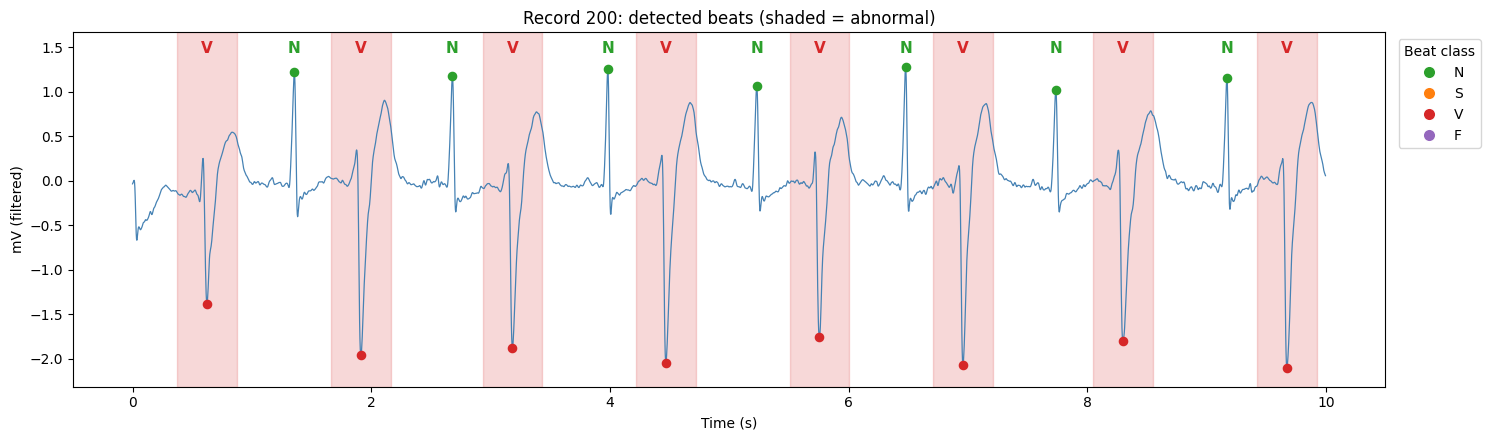

In [15]:
# All 48 MIT-BIH records (DS1 + DS2 + the 4 paced records excluded from the standard split)
PACED_RECORDS = ['102', '104', '107', '217']
ALL_RECORDS = sorted(set(DS1 + DS2 + PACED_RECORDS), key=int)

def ask_and_predict(default_seconds=10):
    """Prompt the user for a record number, validate it, then run predict_record on it.
    Loops until a valid record is entered (or the user types 'q' to cancel)."""
    print(f"Available MIT-BIH records ({len(ALL_RECORDS)}): {', '.join(ALL_RECORDS)}")
    if PACED_RECORDS:
        print(f"Note: {', '.join(PACED_RECORDS)} are paced records outside DS1/DS2 (Q-heavy, not part of training/testing).")
    while True:
        rec = input("\nEnter a record number to analyse (or 'q' to cancel): ").strip()
        if rec.lower() == 'q':
            print("Cancelled.")
            return None
        if rec not in ALL_RECORDS:
            print(f"'{rec}' is not a valid MIT-BIH record. Please choose from the list above.")
            continue
        which = "training (DS1)" if rec in DS1 else ("test (DS2)" if rec in DS2 else "paced (excluded from split)")
        print(f"\nRecord {rec} is in the {which} set.\n")
        return predict_record(rec, plot_seconds=default_seconds)

result = ask_and_predict()

In [16]:
# Detector quality over every test record + class mix per record
print(f"{'rec':<6}{'det.sens':>9}{'det.PPV':>9}   " + "  ".join(f"{c:>5}" for c in CLASSES))
for r in test_records:
    sz, fm, an = load_record(r); pk, pr = classify_signal(fm, sz)
    s, p = evaluate_detection(pk, beat_annotations(an)[0])
    cnt = Counter(np.array(CLASSES)[np.argmax(pr, 1)])
    print(f"{r:<6}{s:>9.3f}{p:>9.3f}   " + "  ".join(f"{cnt.get(c,0):>5}" for c in CLASSES))

rec    det.sens  det.PPV       N      S      V      F
100       0.999    1.000    2241     29      1      0
103       0.999    1.000    2082      0      0      0
105       0.998    0.988    2492      5     91      8
111       1.000    1.000    2052     28     43      0
113       0.999    1.000    1788      5      1      0
117       0.999    1.000     906      1      0    627
121       0.999    1.000    1857      0      5      0
123       0.997    1.000    1514      0      0      0
200       0.998    1.000    1803      5    783      7
202       0.995    1.000    2090     15     20      1
210       0.977    0.999    2479      0    113      0
212       1.000    1.000    2747      0      0      0
213       0.998    1.000    3004      0    155     84
214       0.996    1.000    1970      0    269     13
219       0.996    1.000    1862    228     56      0
221       0.987    1.000    2029      1    366      0
222       0.999    1.000    2020    390     68      3
228       0.998    0.994    

## 11. Edge Deployment — TFLite export

In [17]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('ecg_model_v3.tflite', 'wb') as f: f.write(tflite_model)
print(f"TFLite size: {os.path.getsize('ecg_model_v3.tflite') / 1024:.1f} KB")

# App-side constants the mobile code must reuse
with open('ecg_preproc_v3.json', 'w') as f:
    json.dump({'classes': CLASSES, 'fs': FS, 'window_before': WINDOW_BEFORE, 'window_after': WINDOW_AFTER,
               'rr_mean': RR_MEAN.tolist(), 'rr_std': RR_STD.tolist(), 'bandpass_hz': [0.5, 40]}, f, indent=2)

interp = tf.lite.Interpreter(model_content=tflite_model)
runner = interp.get_signature_runner()
n_check = min(500, len(Xte)); match = 0; import time; t0 = time.time()
for i in range(n_check):
    out = list(runner(waveform=Xte[i:i+1], rr_features=Rte[i:i+1]).values())[0]
    match += int(np.argmax(out) == y_pred[i])
ms = (time.time() - t0) / n_check * 1000
print(f"TFLite vs Keras agreement on {n_check} test beats: {100 * match / n_check:.1f}% | ~{ms:.2f} ms/beat on this machine")

Saved artifact at '/tmp/tmp795q_e3z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 200, 1), dtype=tf.float32, name='waveform'), TensorSpec(shape=(None, 6), dtype=tf.float32, name='rr_features')]
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133995959625744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133995959626704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133995959626128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133995959626512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133995959625552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133995959626320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133995959627280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133995959624976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133995959627088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133995959628048: Ten

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 12. Summary
- All beat classes (N / S / V / F) are now trained, evaluated and **displayed with their own colour and label**.
- Q is dropped by default because DS1/DS2 contain essentially no Q beats; set `USE_Q = True` (and add the paced records to training) if you need it.
- Section 8 gives per-class sensitivity, specificity, macro-F1 and false alarms/min; the diagnostic table shows whether any class is being ignored.
- `ecg_model_v3.tflite` + `ecg_preproc_v3.json` are everything a mobile app needs (the app must also implement: band-pass 0.5–40 Hz → z-score → QRS detection → the same 200-sample window and 6 RR features).
- If S/F recall is still low on real data: raise `target_ratio` (0.4 → 0.7), raise focal `gamma` (2 → 3), or add the second ECG lead (V1) as a second input channel — that is the biggest remaining lever for S-vs-N.